In [8]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms
import matplotlib.pyplot as plt


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [11]:
# Load pretrained ResNet18
model = models.resnet18(pretrained=True)

print('ResNet18 architecture:')
print(model)

print(f'\nFinal layer input features: {model.fc.in_features}')
print(f'Final layer output features: {model.fc.out_features}')

ResNet18 architecture:
ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu)

c:\Users\rafee\ibot_25-26\IBOT-DC-tenure-25-26\cv_bootcamp\.venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\rafee\ibot_25-26\IBOT-DC-tenure-25-26\cv_bootcamp\.venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [12]:
# Examine ResNet layers
print("ResNet18 structure:")
print("="*50)
for name, module in model.named_children():
    print(f"{name:15s}: {module.__class__.__name__}")

print("\nResidual blocks in layer1:")
for i, block in enumerate(model.layer1):
    print(f"  Block {i}: {block}")
     

ResNet18 structure:
conv1          : Conv2d
bn1            : BatchNorm2d
relu           : ReLU
maxpool        : MaxPool2d
layer1         : Sequential
layer2         : Sequential
layer3         : Sequential
layer4         : Sequential
avgpool        : AdaptiveAvgPool2d
fc             : Linear

Residual blocks in layer1:
  Block 0: BasicBlock(
  (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
)
  Block 1: BasicBlock(
  (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (conv2): Conv2d(64, 64, kernel_size=(

In [13]:
# Freeze all layers
for param in model.parameters():
    param.requires_grad = False

# Replace final layer for binary classification (Cat vs Dog)
model.fc = nn.Linear(model.fc.in_features, 2)

model = model.to(device)

print('Modified model final layer:')
print(model.fc)

# Count trainable vs total parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'\nTotal parameters: {total_params:,}')
print(f'Trainable parameters: {trainable_params:,}')
print(f'Frozen parameters: {total_params - trainable_params:,}')
print(f'\n% trainable: {100*trainable_params/total_params:.2f}%')

Modified model final layer:
Linear(in_features=512, out_features=2, bias=True)

Total parameters: 11,177,538
Trainable parameters: 1,026
Frozen parameters: 11,176,512

% trainable: 0.01%


In [14]:
# Only optimize parameters of final layer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

print('Optimizer configured to train only final layer')
print(f'Learning rate: {optimizer.param_groups[0]["lr"]}')
     

Optimizer configured to train only final layer
Learning rate: 0.001


StepLR: Multiply LR by 0.1 every 5 epochs
ReduceLROnPlateau: Reduce LR by 0.5 if no improvement for 3 epochs
CosineAnnealingLR: Smooth decrease following cosine curve


c:\Users\rafee\ibot_25-26\IBOT-DC-tenure-25-26\cv_bootcamp\.venv\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
c:\Users\rafee\ibot_25-26\IBOT-DC-tenure-25-26\cv_bootcamp\.venv\Lib\site-packages\torch\optim\lr_scheduler.py:224: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(


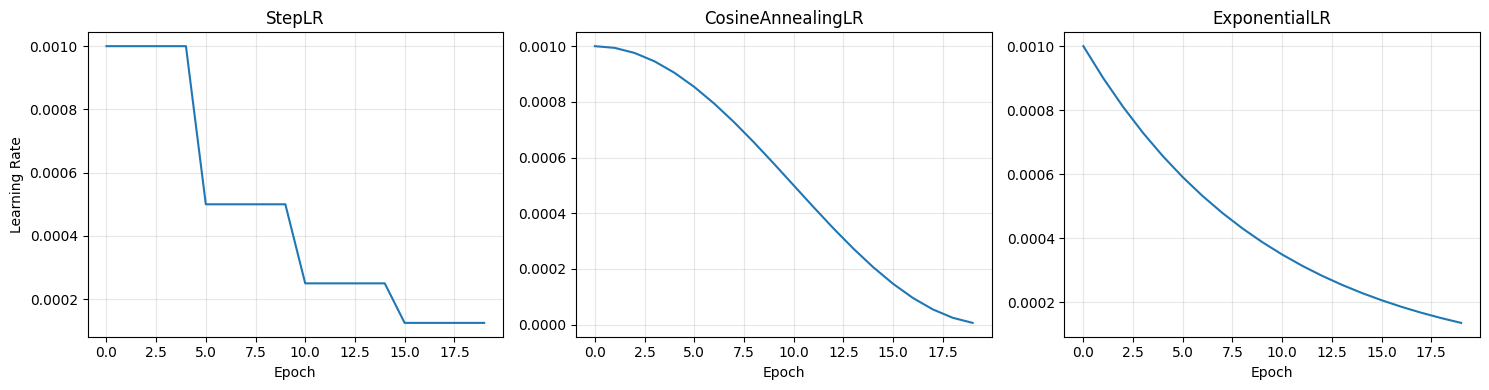

In [15]:
# 1. StepLR: Reduce LR every N epochs
scheduler_step = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)
print("StepLR: Multiply LR by 0.1 every 5 epochs")

# 2. ReduceLROnPlateau: Reduce when validation stops improving
scheduler_plateau = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3, verbose=True
)
print("ReduceLROnPlateau: Reduce LR by 0.5 if no improvement for 3 epochs")

# 3. CosineAnnealingLR: Smooth decrease
scheduler_cosine = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)
print("CosineAnnealingLR: Smooth decrease following cosine curve")

# Visualize schedules
def plot_lr_schedule(scheduler, epochs=20):
    lrs = []
    for epoch in range(epochs):
        lrs.append(optimizer.param_groups[0]['lr'])
        scheduler.step()
    return lrs

# Reset optimizer
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# StepLR
optimizer.param_groups[0]['lr'] = 0.001
sch = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)
lrs = plot_lr_schedule(sch, 20)
axes[0].plot(lrs)
axes[0].set_title('StepLR')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Learning Rate')
axes[0].grid(True, alpha=0.3)

# Cosine
optimizer.param_groups[0]['lr'] = 0.001
sch = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)
lrs = plot_lr_schedule(sch, 20)
axes[1].plot(lrs)
axes[1].set_title('CosineAnnealingLR')
axes[1].set_xlabel('Epoch')
axes[1].grid(True, alpha=0.3)

# Exponential
optimizer.param_groups[0]['lr'] = 0.001
sch = optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.9)
lrs = plot_lr_schedule(sch, 20)
axes[2].plot(lrs)
axes[2].set_title('ExponentialLR')
axes[2].set_xlabel('Epoch')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Reset for actual training
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)
     

In [17]:
# Strategy 1: Train only final layer (what we're doing)
print("Strategy 1: Train only final layer")
print("  - Fastest")
print("  - Needs least data")
print("  - Good for similar tasks to ImageNet\n")

# Strategy 2: Unfreeze last few layers
def unfreeze_last_n_layers(model, n=1):
    """Unfreeze last n residual blocks"""
    layers = [model.layer4, model.layer3, model.layer2, model.layer1]
    for i in range(n):
        for param in layers[i].parameters():
            param.requires_grad = True
    return model

print("Strategy 2: Unfreeze last few layers")
print("  - More flexible")
print("  - Needs more data")
print("  - Better for different tasks\n")

# Strategy 3: Unfreeze all with different learning rates
print("Strategy 3: Different LR for different layers")
print("  - Best results")
print("  - Needs most data")
print("  - Use lower LR for early layers")

# Example of strategy 3
# for param in model.parameters():
#     param.requires_grad = True
# 
# optimizer = optim.Adam([
#     {'params': model.layer4.parameters(), 'lr': 1e-4},
#     {'params': model.layer3.parameters(), 'lr': 1e-5},
#     {'params': model.fc.parameters(), 'lr': 1e-3}
# ])


Strategy 1: Train only final layer
  - Fastest
  - Needs least data
  - Good for similar tasks to ImageNet

Strategy 2: Unfreeze last few layers
  - More flexible
  - Needs more data
  - Better for different tasks

Strategy 3: Different LR for different layers
  - Best results
  - Needs most data
  - Use lower LR for early layers


In [16]:
# ImageNet statistics
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

# Training: WITH augmentation
train_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std)
])

# Validation/Test: NO augmentation
val_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std)
])

print('Transforms defined with ImageNet statistics')
print(f'Mean: {imagenet_mean}')
print(f'Std:  {imagenet_std}')
print('\n⚠ Important: NEVER augment validation/test data!')

Transforms defined with ImageNet statistics
Mean: [0.485, 0.456, 0.406]
Std:  [0.229, 0.224, 0.225]

⚠ Important: NEVER augment validation/test data!


In [18]:
# Load different architectures
resnet18 = models.resnet18(pretrained=True)
resnet50 = models.resnet50(pretrained=True)
mobilenet_v2 = models.mobilenet_v2(pretrained=True)

print('Available pretrained models:')
print('- ResNet family (18, 34, 50, 101, 152)')
print('- VGG family (16, 19)')
print('- MobileNet v2/v3 (mobile-optimized)')
print('- EfficientNet family (b0-b7)')
print('- DenseNet family (121, 161, 169, 201)')

c:\Users\rafee\ibot_25-26\IBOT-DC-tenure-25-26\cv_bootcamp\.venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to C:\Users\rafee/.cache\torch\hub\checkpoints\resnet50-0676ba61.pth
100.0%
c:\Users\rafee\ibot_25-26\IBOT-DC-tenure-25-26\cv_bootcamp\.venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get t

Available pretrained models:
- ResNet family (18, 34, 50, 101, 152)
- VGG family (16, 19)
- MobileNet v2/v3 (mobile-optimized)
- EfficientNet family (b0-b7)
- DenseNet family (121, 161, 169, 201)


In [19]:
models_to_compare = {
    'ResNet18': models.resnet18(pretrained=True),
    'ResNet50': models.resnet50(pretrained=True),
    'MobileNetV2': models.mobilenet_v2(pretrained=True)
}

print('Model Comparison:\n')
print(f'{"Model":<15} {"Parameters":>12} {"Size (MB)":>12} {"Use Case"}')
print('=' * 70)

for name, model in models_to_compare.items():
    params = sum(p.numel() for p in model.parameters())
    size_mb = params * 4 / 1024 / 1024  # Assuming float32
    
    use_case = {
        'ResNet18': 'Quick baseline, learning',
        'ResNet50': 'General purpose, best accuracy',
        'MobileNetV2': 'Mobile/edge deployment'
    }[name]
    
    print(f'{name:<15} {params:>12,} {size_mb:>11.1f} {use_case}')

# Speed test
print('\nInference Speed Test (CPU):')
test_input = torch.randn(1, 3, 224, 224)

import time
for name, model in models_to_compare.items():
    model.eval()
    with torch.no_grad():
        start = time.time()
        for _ in range(10):
            _ = model(test_input)
        elapsed = (time.time() - start) / 10
    print(f'{name:<15}: {elapsed*1000:.1f} ms per image')
     

Model Comparison:

Model             Parameters    Size (MB) Use Case
ResNet18          11,689,512        44.6 Quick baseline, learning
ResNet50          25,557,032        97.5 General purpose, best accuracy
MobileNetV2        3,504,872        13.4 Mobile/edge deployment

Inference Speed Test (CPU):
ResNet18       : 23.3 ms per image
ResNet50       : 38.5 ms per image
MobileNetV2    : 21.4 ms per image


In [20]:
def train_with_transfer_learning(train_loader, val_loader, num_epochs=10):
    """
    Complete transfer learning training loop
    """
    # 1. Load pretrained model
    model = models.resnet18(pretrained=True)
    
    # 2. Freeze all layers
    for param in model.parameters():
        param.requires_grad = False
    
    # 3. Replace final layer
    model.fc = nn.Linear(model.fc.in_features, 2)  # Binary classification
    model = model.to(device)
    
    # 4. Setup training
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.fc.parameters(), lr=0.001)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3)
    
    best_val_acc = 0.0
    
    # 5. Training loop
    for epoch in range(num_epochs):
        # Train
        model.train()
        train_loss = 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
        
        # Validate
        model.eval()
        val_loss = 0
        correct = 0
        total = 0
        
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                
                val_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
        
        val_acc = correct / total
        
        # Update learning rate
        scheduler.step(val_loss)
        
        # Save best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), 'best_model.pth')
        
        print(f'Epoch {epoch+1}: Val Acc = {val_acc*100:.2f}%')
    
    return model

print("Training function defined!")
print("Call with: model = train_with_transfer_learning(train_loader, val_loader)")
     

Training function defined!
Call with: model = train_with_transfer_learning(train_loader, val_loader)
